In [1]:
import mdtraj as md
import numpy as np
import scipy
from scipy.stats import linregress
import matplotlib.pyplot as plt
from itertools import combinations
import sys, os, re
from msmbuilder.decomposition import tICA as msm_tICA
from msmbuilder.featurizer import AtomPairsFeaturizer

sys.path.append(os.path.dirname(os.getcwd())) 
import amuset_tica

In [2]:
tics_of_trajs = np.load("9d9f_inv_2tics.npy")
print(tics_of_trajs.shape)
basis_list = np.array([[[-1.0939795878279368, 2], [0.6151525780598074, 2], [0.6025909988440169, 2], [-0.9219408339178378, 2]], [[-1.0939795878279368, 2], [0.6151525780598074, 2], [0.6025909988440169, 2], [-0.9219408339178378, 2]]])
print(basis_list)

lag_times = list(range(1, 201))
traj_AT, traj_lens = amuset_tica._convert_sequences(tics_of_trajs)
print(traj_AT.shape)

(40, 50001, 2)
[[[-1.09397959  2.        ]
  [ 0.61515258  2.        ]
  [ 0.602591    2.        ]
  [-0.92194083  2.        ]]

 [[-1.09397959  2.        ]
  [ 0.61515258  2.        ]
  [ 0.602591    2.        ]
  [-0.92194083  2.        ]]]
(2, 2000040)


In [10]:
RNG = []
with open('random-number-40.txt', 'r') as f:
    i = 0
    for line in f:
        i += 1
        if i > 40:
            break
        RNG.append(list(map(int, line.split())))

len(RNG), len(RNG[0])

(40, 40)

In [11]:
ttica = amuset_tica.AmusetTICA()
svd_v, _ = ttica.build(basis_list, tics_of_trajs)
svd_full = amuset_tica._convert_to_sequences(svd_v, traj_lens)
print(len(svd_full), svd_full[0].shape)

40 (50001, 25)


In [12]:
lag_times = list(range(1, 201))
Koop_boot = []

for j in range(40):
    svd_v_resam = [svd_full[_] for _ in RNG[j]]
    svd_v_cur, traj_lens_cur = amuset_tica._convert_sequences(svd_v_resam)
    Koop_collect = []
    for i in lag_times[60:100]:
        ttica.covariance(svd_v_cur, traj_lens_cur, lag_time=i)
        Koop_collect.append(ttica._K)
        if i % 15 == 0:
            print("Time =", i, 'frames')
    Koop_boot.append(np.array(Koop_collect))
    print('Round#', j, 'Bootstraping')

Koop_boot = np.array(Koop_boot)
from datetime import datetime
print(f"Current date and time: {datetime.now()}")

Time = 75 frames
Time = 90 frames
Round# 0 Bootstraping
Time = 75 frames
Time = 90 frames
Round# 1 Bootstraping
Time = 75 frames
Time = 90 frames
Round# 2 Bootstraping
Time = 75 frames
Time = 90 frames
Round# 3 Bootstraping
Time = 75 frames
Time = 90 frames
Round# 4 Bootstraping
Time = 75 frames
Time = 90 frames
Round# 5 Bootstraping
Time = 75 frames
Time = 90 frames
Round# 6 Bootstraping
Time = 75 frames
Time = 90 frames
Round# 7 Bootstraping
Time = 75 frames
Time = 90 frames
Round# 8 Bootstraping
Time = 75 frames
Time = 90 frames
Round# 9 Bootstraping
Time = 75 frames
Time = 90 frames
Round# 10 Bootstraping
Time = 75 frames
Time = 90 frames
Round# 11 Bootstraping
Time = 75 frames
Time = 90 frames
Round# 12 Bootstraping
Time = 75 frames
Time = 90 frames
Round# 13 Bootstraping
Time = 75 frames
Time = 90 frames
Round# 14 Bootstraping
Time = 75 frames
Time = 90 frames
Round# 15 Bootstraping
Time = 75 frames
Time = 90 frames
Round# 16 Bootstraping
Time = 75 frames
Time = 90 frames
Round# 

In [13]:
print(Koop_boot.shape)
note = '(n_bootstrap, n_lag_times, Rank, Rank); Bootstraping with 40 trajs for 40 times, and run for all 40 different lag times.'
np.savez('Koopman_bootstrap.npz', data=Koop_boot, lag=lag_times[40:80], note=note)

(40, 40, 25, 25)


In [14]:
load_data = np.load('Koopman_bootstrap.npz')
load_data, load_data['data'].shape

(NpzFile 'Koopman_bootstrap.npz' with keys: data, lag, note, (40, 40, 25, 25))

# regression

In [15]:
load_data = np.load('Koopman_bootstrap.npz')
Ks_boot, lag_boot = load_data['data'], load_data['lag']
Ks = np.load("9d9f_Ks.npy")
lag_times = load_data['lag']
st, en = 65, 85
print(Ks.shape, Ks_boot.shape)

(300, 25, 25) (40, 40, 25, 25)


In [16]:
# ============================================================
# 1. Core regression: fit M from K(t+1) ≈ K(t) M
# ============================================================

def fit_M_from_K_sequence(Ks, st=0, gap=1, num_pair=None, enforce_hermitian_M=False, rcond=None):
    """
    Fit M in the model K(t+1) ≈ K(t) M via least squares.

    Parameters
    ----------
    Ks : list or array-like of shape [T, d, d]
        Sequence of Hermitian (or general) matrices K(t),
        t = 0, ..., T-1.
    enforce_hermitian_M : bool, optional
        If True, M is projected onto the Hermitian cone:
        M <- (M + M^†) / 2
    rcond : float or None
        Passed to np.linalg.lstsq for numerical stability.

    Returns
    -------
    M : (d, d) np.ndarray
        Estimated propagator.
    info : dict
        Some diagnostics: residuals, norms, etc.
    """
    Ks = np.asarray(Ks)
    T, d1, d2 = Ks.shape
    assert d1 == d2, "K(t) must be square."
    if st < 0:
        st = T - st
    assert gap > 0, 'gap must be positive.'
    d = d1

    if T < st + gap + 1:
        raise ValueError("Need at least 2 valid matrices K(t) to fit M.")

    # Build stacked system:
    #   X M ≈ Y
    # where X = block rows of K(0..T-2), Y = block rows of K(1..T-1)
    X = Ks[st:-gap].reshape(-1, d)
    Y = Ks[st+gap:].reshape(-1, d)

    # Solve least squares: X M ≈ Y
    # np.linalg.lstsq handles complex numbers and uses SVD internally.
    M, residuals, rank, s = np.linalg.lstsq(X, Y, rcond=rcond)

    if enforce_hermitian_M:
        M = 0.5 * (M + M.conj().T)

    # Compute residuals in matrix form: R(t) = K(t+1) - K(t) M
    R_list = []
    rel_norms = []
    end_point = T-gap
    if num_pair and num_pair < end_point - st:
        end_point = st+num_pair
    for t in range(st, end_point):
        K_pred = Ks[t] @ M
        R = Ks[t + gap] - K_pred
        R_list.append(R)
        num = np.linalg.norm(R, ord="fro")
        den = np.linalg.norm(Ks[t + gap], ord="fro") + 1e-15
        rel_norms.append(num / den)

    info = {
        "residuals": np.array(R_list),      # shape: (T-1, d, d)
        "relative_residual_norms": np.array(rel_norms),  # length T-1
        "lstsq_residuals_raw": residuals,
        "rank_X": rank,
        "singular_values_X": s,
    }

    return M, info


# ============================================================
# 2. Fit A from K(0) ≈ A M
# ============================================================

def fit_A_from_K0_and_M(K0, M):
    """
    Fit A in the model K(0) ≈ A M using pseudoinverse.

    Parameters
    ----------
    K0 : (d, d) array
        First matrix in the sequence, K(0).
    M : (d, d) array
        Propagator matrix.

    Returns
    -------
    A : (d, d) array
    """
    M_pinv = np.linalg.pinv(M)
    A = K0 @ M_pinv
    return A


# ============================================================
# 3. Generate predicted K(t) from A and M
# ============================================================

def generate_K_from_A_M(A, M, T):
    """
    Generate model-predicted K(t) = A M^t for t = 0..T-1.

    Parameters
    ----------
    A : (d, d) array
    M : (d, d) array
    T : int
        Number of time steps.

    Returns
    -------
    K_model : (T, d, d) array
    """
    d = A.shape[0]
    K_model = np.zeros((T, d, d), dtype=complex if np.iscomplexobj(A) or np.iscomplexobj(M) else float)
    Mt = np.eye(d, dtype=K_model.dtype)
    for t in range(T):
        Mt = Mt @ M
        K_model[t] = A @ Mt
    return K_model


In [20]:
# Ks_loop start with lag=1ps 
K_mean, K_std = [], []
for lt in range(st, en+10):
    cur_mean, cur_std = np.zeros((25, 25), dtype=np.float64), np.zeros((25, 25), dtype=np.float64)
    for i in range(25):
        for j in range(25):
            arr = Ks_boot[:, lt-60, i, j] # lag_times of Ks_boot starts @ 61
            cur_mean[i][j], cur_std[i][j] = np.mean(arr), np.std(arr)
    K_mean.append(cur_mean)
    K_std.append(cur_std)
print(len(K_mean), K_mean[0].shape)

30 (25, 25)


In [21]:
Ks[st:].shape, Ks_model.shape

((235, 25, 25), (235, 25, 25))

In [22]:
def plot_all_entries(Ks_true, Ks_model, r, c, y_lim_range = .01, fig_size = (18, 18)):
    
    Ks_true = np.asarray(Ks_true)
    Ks_model = np.asarray(Ks_model)
    t = np.arange(len(Ks_true))
    
    fig, axes = plt.subplots(r, c, figsize=fig_size, sharex=True)
    fig.suptitle("Observed vs Model-predicted K[i,j] entries", fontsize=20)

    for i in range(r):
        for j in range(c):
            ax = axes[i, j]
            y_true = Ks_true[:, i, j]
            y_pred = Ks_model[:, i, j]
            
            if True:#i!=j:
                max_true, min_true = np.max(y_true), np.min(y_true)
                if max_true - min_true < y_lim_range:
                    mid_true = .5* (max_true + min_true)
                    ax.set_ylim([mid_true-y_lim_range*.55, mid_true+y_lim_range*.55])
                else:
                    ax.set_ylim([min_true*1.05-max_true*.05, max_true*1.05-min_true*.05])
            
            ax.plot(t, y_true, label="true", color="black")
            ax.plot(t, y_pred, linestyle="dashdot", color="orange")
            ax.set_title(f"[{i},{j}]", fontsize=8)
            # Smaller ticks for large grid
            ax.tick_params(axis="both", which="major", labelsize=6)

    # Put legend only once outside the grid
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=10)
    plt.show()

def plot_error_bar(Ks_pred, Ks_true, Ks_err, rc, y_lim_range = .01, fig_size = (18, 18)):
    Ks_pred, Ks_true, Ks_err = np.asarray(Ks_pred), np.asarray(Ks_true), np.asarray(Ks_err)
    t = np.arange(len(Ks_true))
    length = len(rc)
    r, c = [_[0] for _ in rc], [_[1] for _ in rc]
    size = int(np.ceil(np.sqrt(length)))
    fig, axes = plt.subplots(int(np.ceil(length/size)), size, figsize=fig_size, sharex=True)
    fig.suptitle("Observed vs Model-predicted K[i,j] entries", fontsize=20)

    for idx in range(length):
        ax = axes[idx//size, idx%size]
        y_pred = Ks_pred[:, r[idx], c[idx]]
        y_true = Ks_true[:, r[idx], c[idx]]
        y_err = Ks_err[:, r[idx], c[idx]]

        max_true, min_true = np.max(y_true), np.min(y_true)
        if max_true - min_true < y_lim_range:
            mid_true = .5* (max_true + min_true)
            ax.set_ylim([mid_true-y_lim_range*.55, mid_true+y_lim_range*.55])
        else:
            ax.set_ylim([min_true*1.05-max_true*.05, max_true*1.05-min_true*.05])

        ax.plot(t, y_pred, linestyle="dashdot", label='Predicted K', color="orange")
        ax.errorbar(t, y_true, yerr=y_err, fmt='o', capsize=3, color="black", label='True w/ 1sigma')
        ax.set_title(f"[{r[idx]},{c[idx]}]", fontsize=8)
        # Smaller ticks for large grid
        ax.tick_params(axis="both", which="major", labelsize=6)

    # Put legend only once outside the grid
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=10)
    plt.xticks([])
    plt.show()


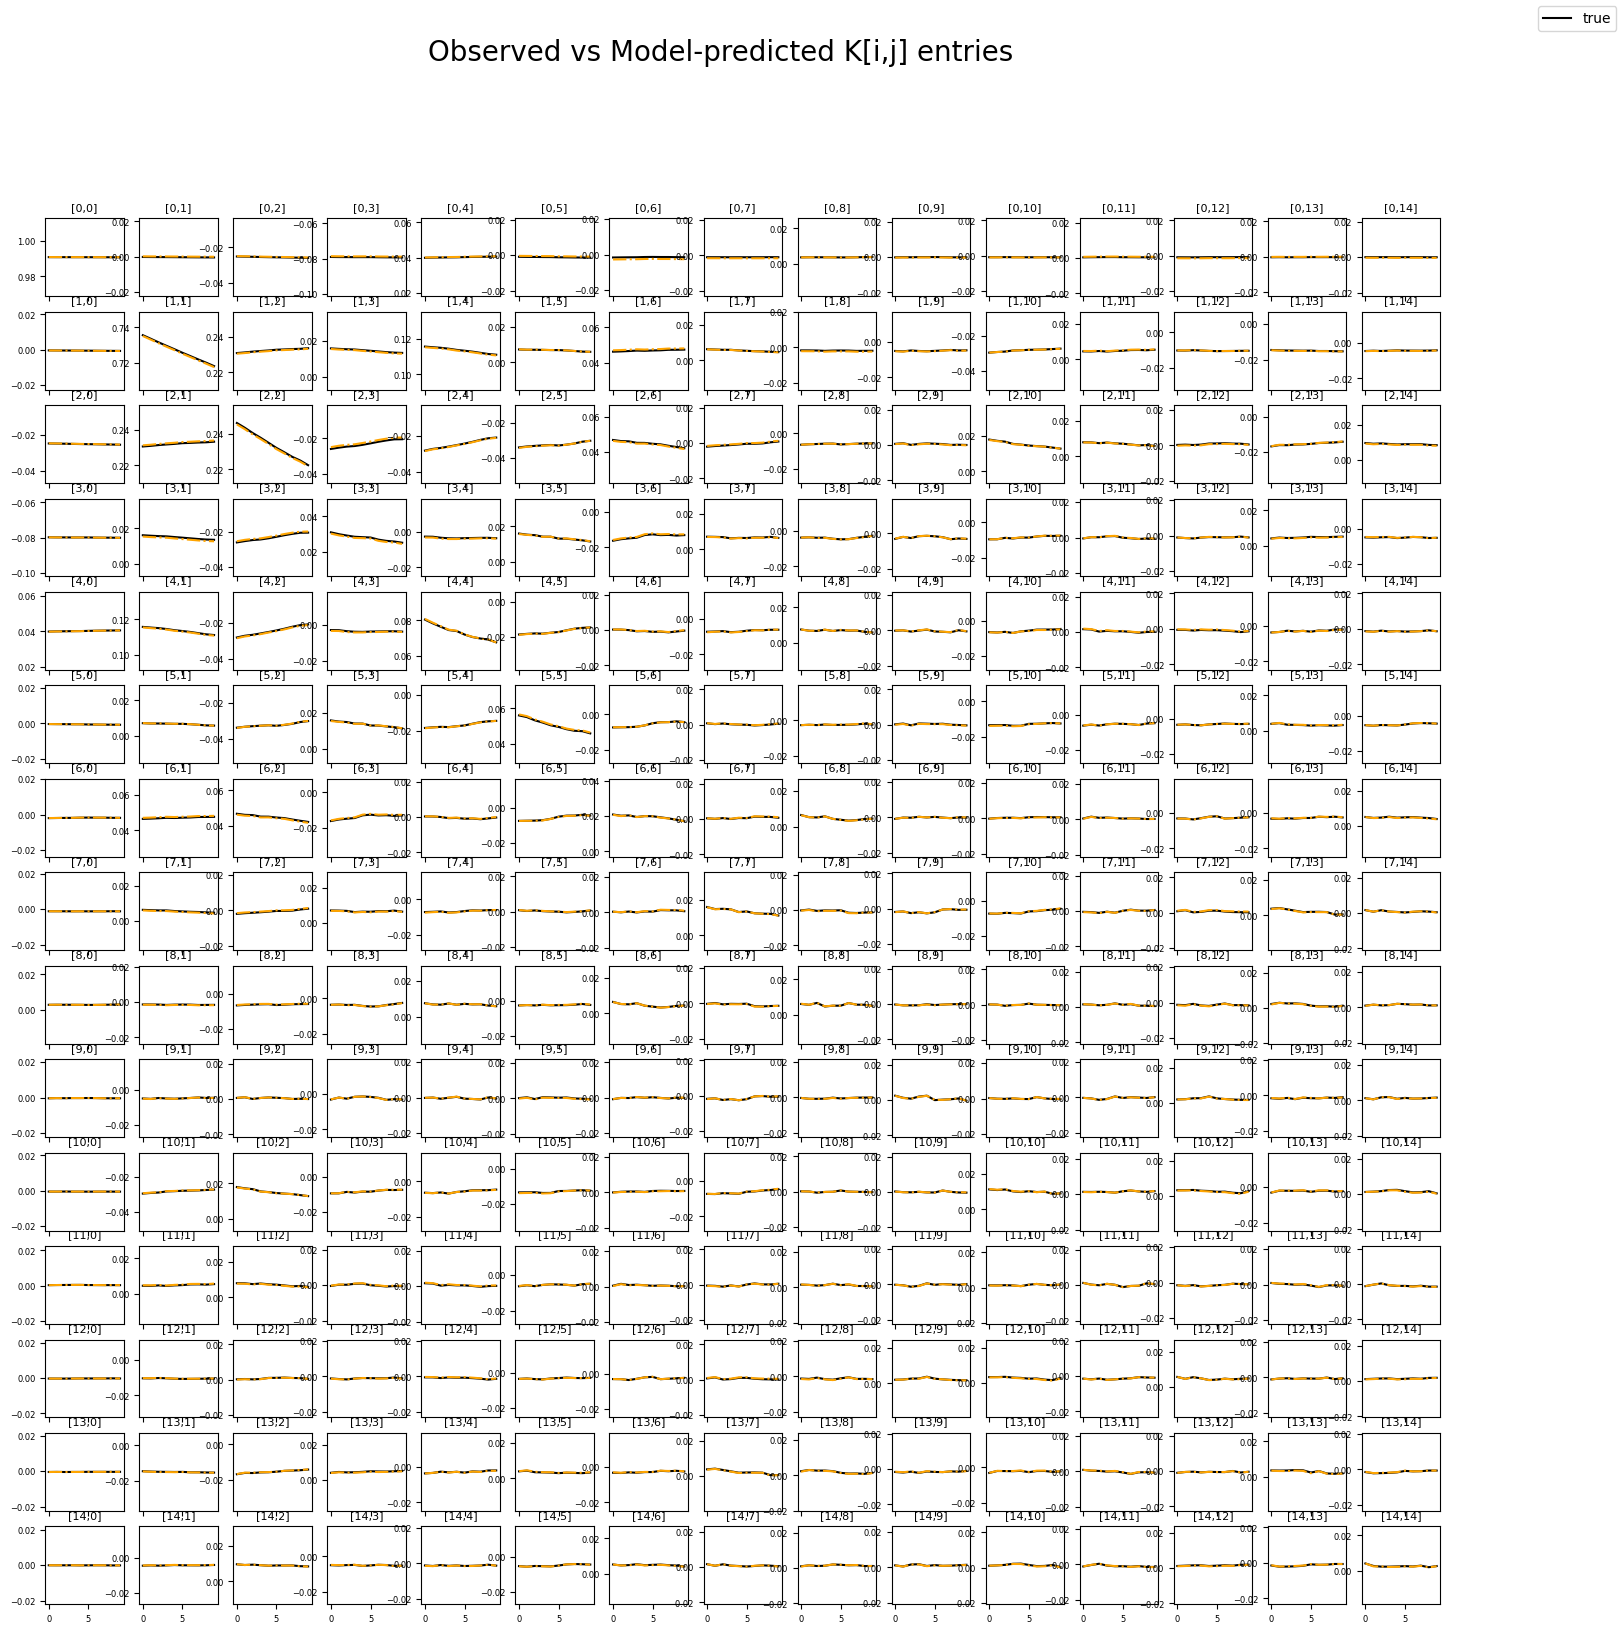

In [23]:
plot_all_entries(Ks[st:st+10], K_mean[:10], 15, 15, y_lim_range=.04)

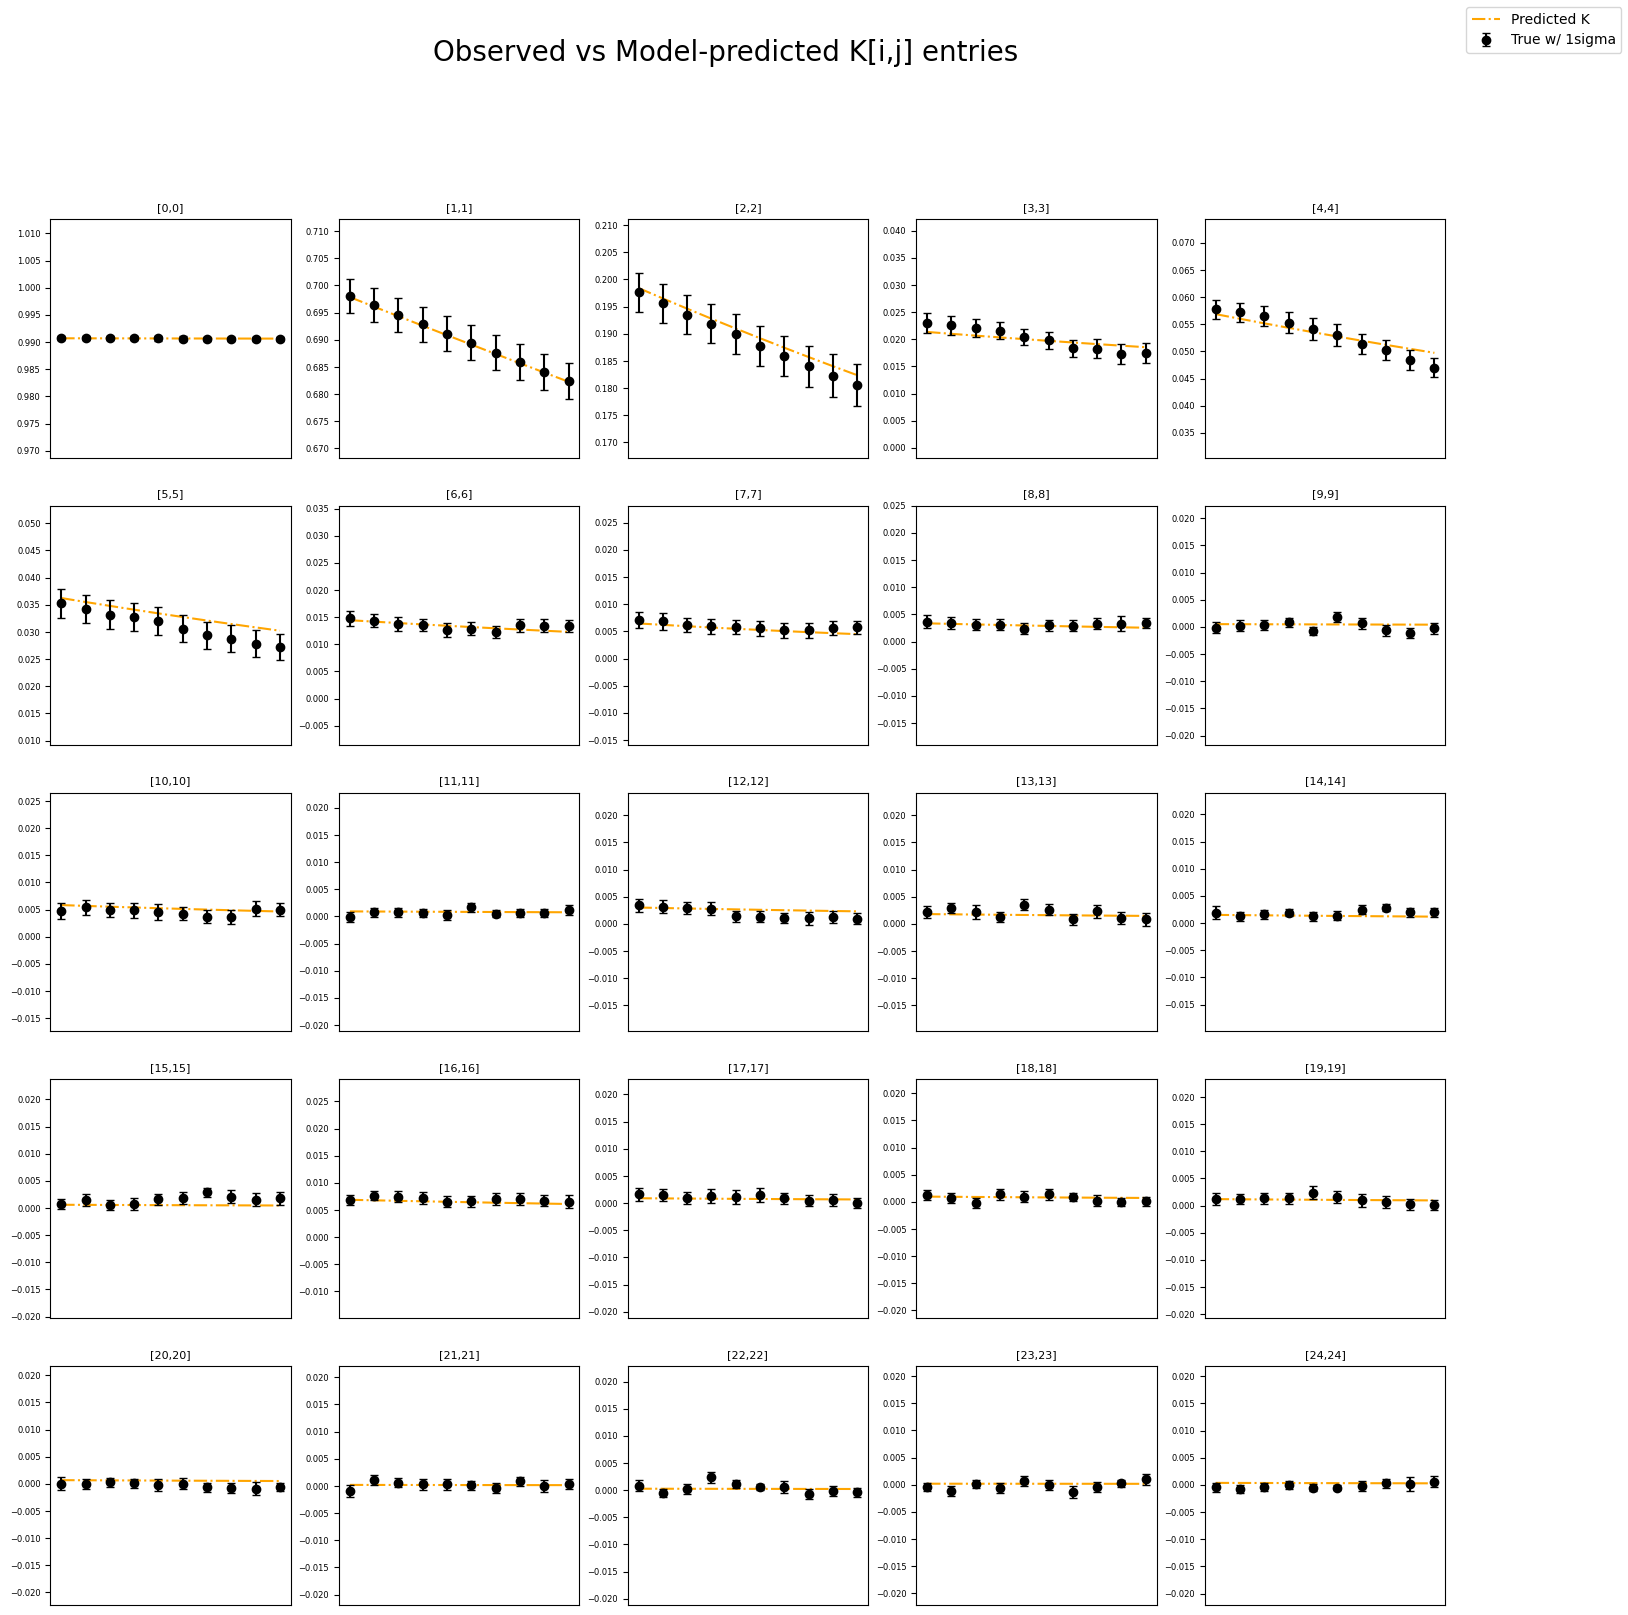

In [24]:
plot_error_bar(Ks_model[en-st:en-st+10], Ks[en:en+10], K_std[en-st:en-st+10], [[i,i] for i in range(25)], y_lim_range = .04)

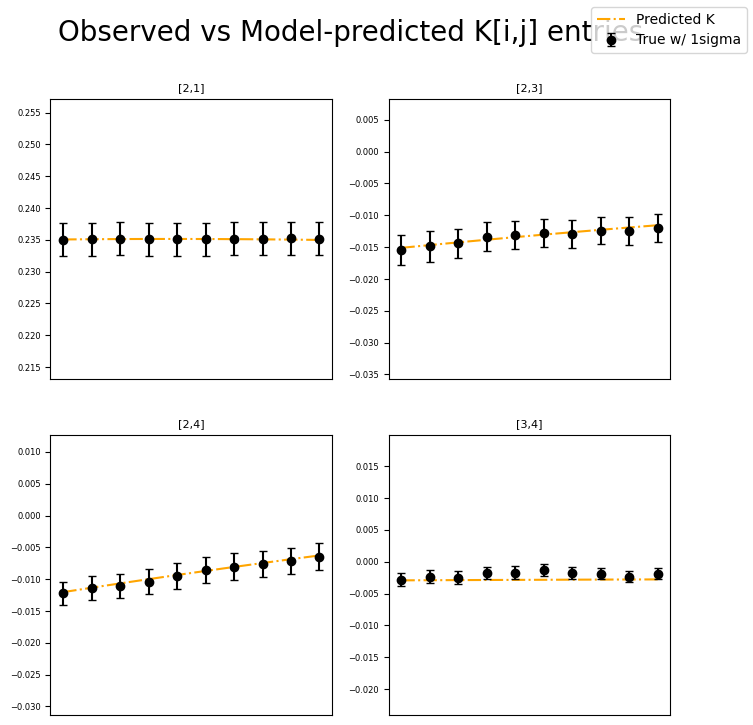

In [25]:
plot_error_bar(Ks_model[en-st:en-st+10], Ks[en:en+10], K_std[en-st:en-st+10], [[2, 1], [2, 3], [2, 4], [3, 4]], y_lim_range = .04, fig_size=(8,8))

In [41]:
Kpred, Ktrue, Kerr = np.asarray(Ks_model[en-st:en-st+10]), np.asarray(Ks[en:en+10]), np.asarray(K_std[en-st:en-st+10])
usage_errorbar = '''
def plot_error_bar(Ks_pred, Ks_true, Ks_err, rc, y_lim_range = .01, fig_size = (18, 18)):
    Ks_pred, Ks_true, Ks_err = np.asarray(Ks_pred), np.asarray(Ks_true), np.asarray(Ks_err)
    t = np.arange(len(Ks_true))
    length = len(rc)
    r, c = [_[0] for _ in rc], [_[1] for _ in rc]
    size = int(np.ceil(np.sqrt(length)))
    fig, axes = plt.subplots(int(np.ceil(length/size)), size, figsize=fig_size, sharex=True)
    fig.suptitle("Observed vs Model-predicted K[i,j] entries", fontsize=20)

    for idx in range(length):
        ax = axes[idx//size, idx%size]
        y_pred = Ks_pred[:, r[idx], c[idx]]
        y_true = Ks_true[:, r[idx], c[idx]]
        y_err = Ks_err[:, r[idx], c[idx]]

        max_true, min_true = np.max(y_true), np.min(y_true)
        if max_true - min_true < y_lim_range:
            mid_true = .5* (max_true + min_true)
            ax.set_ylim([mid_true-y_lim_range*.55, mid_true+y_lim_range*.55])
        else:
            ax.set_ylim([min_true*1.05-max_true*.05, max_true*1.05-min_true*.05])

        ax.plot(t, y_pred, linestyle="dashdot", label='Predicted K', color="orange")
        ax.errorbar(t, y_true, yerr=y_err, fmt='o', capsize=3, color="black", label='True w/ 1sigma')
        ax.set_title(f"[{r[idx]},{c[idx]}]", fontsize=8)
        # Smaller ticks for large grid
        ax.tick_params(axis="both", which="major", labelsize=6)

    # Put legend only once outside the grid
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=10)
    plt.xticks([])
    plt.show()

plot_error_bar(Kpred, Ktrue, Kerr, [[i,i] for i in range(25)], y_lim_range = .04)
'''
np.savez('Panel_1c_BootS.npz', Kpred=Kpred, Ktrue=Ktrue, Kerr=Kerr, usage=usage_errorbar)

# tICs and Selections

In [28]:
def gaussian_amp(x, mu, sigma, A=1):
    return A * np.exp(-(x-mu)**2/(2*sigma**2))

basis_list

array([[[-1.09397959,  2.        ],
        [ 0.61515258,  2.        ],
        [ 0.602591  ,  2.        ],
        [-0.92194083,  2.        ]],

       [[-1.09397959,  2.        ],
        [ 0.61515258,  2.        ],
        [ 0.602591  ,  2.        ],
        [-0.92194083,  2.        ]]])

In [31]:
x_tIC 

array([-1.3839221 , -1.34362991, -1.30333773, -1.26304554, -1.22275336,
       -1.18246117, -1.14216899, -1.10187681, -1.06158462, -1.02129244,
       -0.98100025, -0.94070807, -0.90041588, -0.8601237 , -0.81983151,
       -0.77953933, -0.73924714, -0.69895496, -0.65866277, -0.61837059,
       -0.5780784 , -0.53778622, -0.49749403, -0.45720185, -0.41690966,
       -0.37661748, -0.33632529, -0.29603311, -0.25574092, -0.21544874,
       -0.17515656, -0.13486437, -0.09457219, -0.05428   , -0.01398782,
        0.02630437,  0.06659655,  0.10688874,  0.14718092,  0.18747311,
        0.22776529,  0.26805748,  0.30834966,  0.34864185,  0.38893403,
        0.42922622,  0.4695184 ,  0.50981059,  0.55010277,  0.59039496,
        0.63068714,  0.67097933,  0.71127151,  0.75156369,  0.79185588,
        0.83214806,  0.87244025,  0.91273243,  0.95302462,  0.9933168 ,
        1.03360899,  1.07390117,  1.11419336,  1.15448554,  1.19477773,
        1.23506991,  1.2753621 ,  1.31565428,  1.35594647,  1.39

Counts per bin: [    95   1692  13046  46694  90620 113584 108486  87507  65646  48761
  37581  30128  25422  22630  21448  21066  20792  20604  19018  18039
  16824  15950  14765  14174  13665  13303  12967  12846  12401  12127
  11865  11495  10985  11046  11176  11248  11392  11841  12864  13250
  13874  14443  15072  15153  15834  16138  16547  17545  18808  20655
  23209  26824  31386  35643  38542  41347  42283  42356  40542  38943
  36495  34231  31718  29977  27738  25792  23763  21930  19840  18398
  16843  15110  13904  12696  11874  10620   9977   8858   7767   6498
   5242   4122   3065   2411   1858   1476   1040    740    557    412
    287    210    147    101     69     42     24     13      5      3]


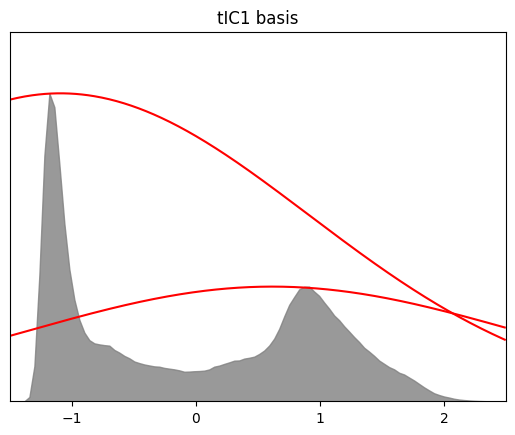

In [32]:
counts, bin_edges = np.histogram(traj_AT[0], bins=100)
print("Counts per bin:", counts)
x_tIC = bin_edges[:-1]+(bin_edges[1]-bin_edges[0])*.5
#plt.plot(x_tIC, counts, color='gray')
plt.fill_between(x_tIC, counts, color='gray', alpha=0.8)

x_min, x_max = -1.5, 2.5
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), basis_list[0][0][0], 2, A=113584), color='r')
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), basis_list[0][1][0], 2, A=42356), color='r')
#plt.axvline(x=basis_list[0][0][0], color='r', linestyle='--', linewidth=.5)
#plt.axvline(x=basis_list[0][1][0], color='r', linestyle='--', linewidth=.5)
plt.ylim([100, np.max(counts)*1.2])
plt.xlim([x_min, x_max])
plt.xticks([-1, 0 ,1, 2])
plt.yticks([])
plt.title('tIC1 basis')
plt.show()

In [33]:
usage1 = '''
def gaussian_amp(x, mu, sigma, A=1):
    return A * np.exp(-(x-mu)**2/(2*sigma**2))

plt.fill_between(x_tIC, counts, color='gray', alpha=0.8)
plt.plot(x_tIC, counts, color='gray')
mu1, mu2 = -1.09397959, 0.61515258
x_min, x_max = -1.5, 2.5
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), mu1, 2, A=113584), color='r')
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), mu2, 2, A=42356), color='r')
plt.ylim([100, np.max(counts)*1.2])
plt.xlim([x_min, x_max])
plt.xticks([-1, 0 ,1, 2])
plt.yticks([])
plt.title('tIC1 basis')
plt.show()
'''
np.savez('Panel_1b1_tICexpansion.npz', x_tIC=x_tIC, counts=counts, usage=usage1)

Counts per bin: [    4    13    21    46    96   159   237   393   533   767  1120  1454
  1963  2580  3170  3892  4868  5804  6839  7744  8767 10137 11391 12606
 13934 15314 16469 18153 19657 20885 22966 24359 25737 27401 28733 30002
 31533 32645 33587 35021 36387 37644 38479 39201 40513 41196 42761 44147
 45301 46332 47347 49223 50501 51689 54018 55311 56557 57696 58907 59404
 58884 57779 55625 52807 49764 45805 41043 36009 31027 25561 20649 16684
 12905 10322  8593  7251  6258  5374  4716  3888  3233  2681  2207  1766
  1473  1094   853   635   492   317   254   173   113    72    55    25
    16    12     6     5]


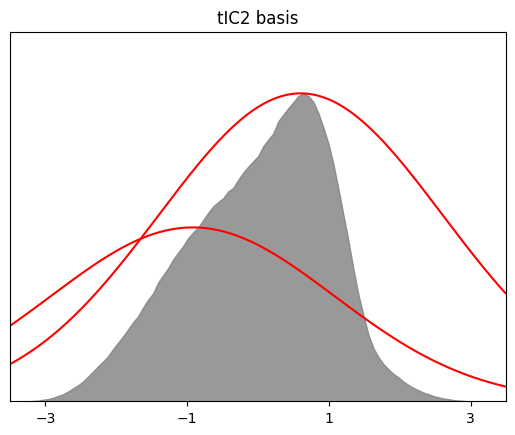

In [39]:
counts, bin_edges = np.histogram(traj_AT[1], bins=100)
print("Counts per bin:", counts)
x_tIC = bin_edges[:-1]+(bin_edges[1]-bin_edges[0])*.5
#plt.plot(x_tIC, counts, color='gray')
plt.fill_between(x_tIC, counts, color='gray', alpha=0.8)

x_min, x_max = -3.5, 3.5
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), basis_list[1][2][0], 2, A=59404), color='r')
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), basis_list[1][3][0], 2, A=33587), color='r')
#plt.axvline(x=basis_list[0][0][0], color='r', linestyle='--', linewidth=.5)
#plt.axvline(x=basis_list[0][1][0], color='r', linestyle='--', linewidth=.5)
plt.ylim([100, np.max(counts)*1.2])
plt.xlim([x_min, x_max])
plt.xticks([-3, -1, 1 ,3])
plt.yticks([])
plt.title('tIC2 basis')
plt.show()

In [40]:
usage2 = '''
def gaussian_amp(x, mu, sigma, A=1):
    return A * np.exp(-(x-mu)**2/(2*sigma**2))

plt.fill_between(x_tIC, counts, color='gray', alpha=0.8)
plt.plot(x_tIC, counts, color='gray')
mu1, mu2 = -0.92194083, 0.602591
x_min, x_max = -3.5, 3.5
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), mu1, 2, A=59404), color='r')
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), mu2, 2, A=33587), color='r')
plt.ylim([100, np.max(counts)*1.2])
plt.xlim([x_min, x_max])
plt.xticks([-3, -1, 1 ,3])
plt.yticks([])
plt.title('tIC2 basis')
plt.show()
'''
np.savez('Panel_1b2_tICexpansion.npz', x_tIC=x_tIC, counts=counts, usage=usage2)